# Tarea 5 IA Generacion de imagenes con autoencoder
### Javier Alonso Rojas Rojas, Brandon Emmanuel Sanchez Araya, Julio Josue Varela Venegas

In [11]:
import os
import torch
from torch import nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import DataLoader
import lightning as L
import hydra

# Modelo clasico AutoEncoder

In [12]:
import torch.nn as nn

class ClassicAE(nn.Module):
    def __init__(self, latent_dim=128, **kwargs):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),   # (B, 32, 64, 64)
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # (B, 64, 32, 32)
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # (B, 128, 16, 16)
            nn.ReLU(),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),# (B, 256, 8, 8)
            nn.ReLU(),
        )
        self.flatten = nn.Flatten()  # output = 256*8*8 = 16384
        self.fc_mu = nn.Linear(256 * 8 * 8, latent_dim)


        self.fc_decode = nn.Linear(latent_dim, 256 * 8 * 8)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), # 16x16
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 32x32
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # 64x64
            nn.ReLU(),

            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),    # 128x128
            nn.Sigmoid()  # imágen RGB normalizada 0–1
        )

    def forward(self, x):
        # Encode
        z = self.encoder(x)
        z = self.flatten(z)
        z = self.fc_mu(z)

        # Decode
        out = self.fc_decode(z)
        out = out.view(-1, 256, 8, 8)
        out = self.decoder(out)

        return out, z

# Modelo de Unet AutoEncoder

In [13]:
import torch
import torch.nn as nn

class UNetAE(nn.Module):
    def __init__(self, latent_dim=128, **kwargs):
        super().__init__()
        
        # ============================================
        # ENCODER con capas individuales para skip connections
        # ============================================
        self.enc1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),   # (B, 32, 64, 64)
            nn.ReLU()
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # (B, 64, 32, 32)
            nn.ReLU()
        )
        self.enc3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # (B, 128, 16, 16)
            nn.ReLU()
        )
        self.enc4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),# (B, 256, 8, 8)
            nn.ReLU()
        )
        
        # ============================================
        # BOTTLENECK (Latent Space)
        # ============================================
        self.flatten = nn.Flatten()  # 256*8*8 = 16384
        self.fc_mu = nn.Linear(256 * 8 * 8, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, 256 * 8 * 8)
        
        # ============================================
        # DECODER con skip connections
        # ============================================
        # Nota: Los canales de entrada se duplican por las skip connections
        
        self.dec1 = nn.Sequential(
            # 256 (from bottleneck) + 256 (skip from enc4) = 512 input channels
            nn.ConvTranspose2d(256 + 256, 128, kernel_size=4, stride=2, padding=1), # 16x16
            nn.ReLU()
        )
        self.dec2 = nn.Sequential(
            # 128 (from dec1) + 128 (skip from enc3) = 256 input channels
            nn.ConvTranspose2d(128 + 128, 64, kernel_size=4, stride=2, padding=1),  # 32x32
            nn.ReLU()
        )
        self.dec3 = nn.Sequential(
            # 64 (from dec2) + 64 (skip from enc2) = 128 input channels
            nn.ConvTranspose2d(64 + 64, 32, kernel_size=4, stride=2, padding=1),   # 64x64
            nn.ReLU()
        )
        self.dec4 = nn.Sequential(
            # 32 (from dec3) + 32 (skip from enc1) = 64 input channels
            nn.ConvTranspose2d(32 + 32, 3, kernel_size=4, stride=2, padding=1),    # 128x128
            nn.Sigmoid()  # imagen RGB normalizada 0-1
        )
    
    def forward(self, x):
        # ============================================
        # ENCODER - Guardar skip connections
        # ============================================
        skip1 = self.enc1(x)       # (B, 32, 64, 64)
        skip2 = self.enc2(skip1)   # (B, 64, 32, 32)
        skip3 = self.enc3(skip2)   # (B, 128, 16, 16)
        skip4 = self.enc4(skip3)   # (B, 256, 8, 8)
        
        # ============================================
        # BOTTLENECK
        # ============================================
        z = self.flatten(skip4)
        z = self.fc_mu(z)
        
        # ============================================
        # DECODER - Usar skip connections
        # ============================================
        out = self.fc_decode(z)
        out = out.view(-1, 256, 8, 8)
        
        # Concatenar skip connection 4
        out = torch.cat([out, skip4], dim=1)  # (B, 512, 8, 8)
        out = self.dec1(out)                   # (B, 128, 16, 16)
        
        # Concatenar skip connection 3
        out = torch.cat([out, skip3], dim=1)  # (B, 256, 16, 16)
        out = self.dec2(out)                   # (B, 64, 32, 32)
        
        # Concatenar skip connection 2
        out = torch.cat([out, skip2], dim=1)  # (B, 128, 32, 32)
        out = self.dec3(out)                   # (B, 32, 64, 64)
        
        # Concatenar skip connection 1
        out = torch.cat([out, skip1], dim=1)  # (B, 64, 64, 64)
        out = self.dec4(out)                   # (B, 3, 128, 128)
        
        return out, z

# Instanciador de Modulo de Pytorch Lightining

In [14]:
import os
import wandb
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

#Lightning Module
class LitAutoencoder(L.LightningModule):
    def __init__(self, cfg):
        super().__init__()
        self.save_hyperparameters()
        self.model = hydra.utils.instantiate(cfg.model)
        self.loss_fn = hydra.utils.instantiate(cfg.loss)
        self.lr = cfg.trainer.learning_rate

        # Para visualizaciones
        self.class_samples = {}
        self.classes = ["cable", "capsule", "screw", "transistor"]
        self.train_loss_history = []
        self.val_loss_history = []
        self.current_train_losses = []

        # Para análisis
        self.latent_vectors = []
        self.latent_labels = []

    def training_step(self, batch, batch_idx):
        x, _ = batch
        x_rec, _ = self.model(x)
        loss = self.loss_fn(x_rec, x)
        self.current_train_losses.append(loss.detach().cpu().item())
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def on_train_epoch_end(self):
        if self.current_train_losses:
            avg_loss = sum(self.current_train_losses) / len(self.current_train_losses)
            self.train_loss_history.append(avg_loss)
            self.current_train_losses = []

    def validation_step(self, batch, batch_idx):
        x, paths = batch
        x_rec, z = self.model(x)
        loss = self.loss_fn(x_rec, x)

        # Guardar para t-SNE
        for i, path in enumerate(paths):
            class_name = path.split("/")[-4]  # cable, capsule, etc.
            self.latent_vectors.append(z[i].detach().cpu())
            self.latent_labels.append(class_name)

        # Guardar muestras por clase
        for i, p in enumerate(paths):
            clase = p.split("/")[-4]
            if clase in self.classes:
                if clase not in self.class_samples:
                    self.class_samples[clase] = []
                if len(self.class_samples[clase]) < 2:
                    self.class_samples[clase].append((
                        x[i].detach().cpu(),
                        x_rec[i].detach().cpu()
                    ))

        self.log("val_loss", loss, prog_bar=True)
        return loss

    def on_validation_epoch_end(self):
        # Reconstrucciones por clase cada 10 épocas
        if self.current_epoch % 10 == 0 or self.current_epoch == self.trainer.max_epochs - 1:
            self._log_reconstructions()

        # t-SNE cada 20 épocas
        if self.current_epoch % 20 == 0 and len(self.latent_vectors) > 0:
            self._log_tsne_analysis()

        # Reset
        self.class_samples = {}
        self.latent_vectors = []
        self.latent_labels = []

    def test_step(self, batch, batch_idx):
        x, paths = batch
        x_rec, _ = self.model(x)
        loss = self.loss_fn(x_rec, x)

        # Guardar para análisis de test
        if not hasattr(self, 'test_samples'):
            self.test_samples = []

        for i in range(min(4, len(x))):
            is_anomaly = "good" not in paths[i]
            self.test_samples.append({
                'original': x[i].cpu(),
                'reconstructed': x_rec[i].cpu(),
                'is_anomaly': is_anomaly,
                'path': paths[i]
            })

        self.log("test_loss", loss)
        return loss

    def on_test_epoch_end(self):
        if hasattr(self, 'test_samples'):
            self._log_test_reconstructions()
            self._log_error_histograms()

    def _log_reconstructions(self):
        """Log reconstrucciones de validación a WandB y plotear en notebook (2 imágenes por clase, horizontal, compacto)."""

        imgs = []

        fig_rows = len(self.classes)
        fig_cols = 4  # orig1, rec1, orig2, rec2

        # Figura más pequeña (antes era 4 * cols, 3 * rows)
        fig, axes = plt.subplots(
            fig_rows,
            fig_cols,
            figsize=(fig_cols * 2.0, fig_rows * 1.6)  # <<< tamaño reducido
        )

        if fig_rows == 1:
            axes = [axes]

        for row, clase in enumerate(self.classes):

            if clase not in self.class_samples or len(self.class_samples[clase]) < 2:
                for col in range(fig_cols):
                    axes[row][col].axis("off")
                continue

            # tomar exactamente DOS pares (orig, rec)
            (orig1, rec1), (orig2, rec2) = self.class_samples[clase][:2]

            # === W&B LOG ===
            imgs.append(wandb.Image(orig1.permute(1,2,0).numpy(), caption=f"{clase}_orig1"))
            imgs.append(wandb.Image(rec1.permute(1,2,0).numpy(), caption=f"{clase}_rec1"))
            imgs.append(wandb.Image(orig2.permute(1,2,0).numpy(), caption=f"{clase}_orig2"))
            imgs.append(wandb.Image(rec2.permute(1,2,0).numpy(), caption=f"{clase}_rec2"))

            # === NOTEBOOK PLOTS ===
            axes[row][0].imshow(orig1.permute(1, 2, 0))
            axes[row][0].set_title(f"{clase} — orig 1", fontsize=8)
            axes[row][0].axis("off")

            axes[row][1].imshow(rec1.permute(1, 2, 0))
            axes[row][1].set_title(f"{clase} — rec 1", fontsize=8)
            axes[row][1].axis("off")

            axes[row][2].imshow(orig2.permute(1, 2, 0))
            axes[row][2].set_title(f"{clase} — orig 2", fontsize=8)
            axes[row][2].axis("off")

            axes[row][3].imshow(rec2.permute(1, 2, 0))
            axes[row][3].set_title(f"{clase} — rec 2", fontsize=8)
            axes[row][3].axis("off")

        plt.suptitle(f"Reconstructions (Notebook) — Epoch {self.current_epoch}", fontsize=12)
        plt.tight_layout()
        plt.show()

        # === W&B LOG ===
        if imgs:
            self.logger.experiment.log({
                "val_reconstructions": imgs,
                "epoch": self.current_epoch
            })




    def _log_tsne_analysis(self):
        """Análisis t-SNE del espacio latente (compacto para notebook)."""

        if len(self.latent_vectors) < 10:
            return

        vectors = torch.stack(self.latent_vectors)
        tsne = TSNE(
            n_components=2,
            random_state=42,
            perplexity=min(30, len(vectors) - 1)
        )
        vectors_2d = tsne.fit_transform(vectors.numpy())

        # === FIGURA MÁS PEQUEÑA ===
        plt.figure(figsize=(6, 5))  # <<< reducido

        for class_name in set(self.latent_labels):
            indices = [i for i, label in enumerate(self.latent_labels) if label == class_name]
            plt.scatter(
                vectors_2d[indices, 0],
                vectors_2d[indices, 1],
                label=class_name,
                alpha=0.6,
                s=18  # <<< puntos más pequeños
            )

        plt.legend(fontsize=8)  # <<< leyenda más pequeña
        plt.title(f"t-SNE Latent Space — Epoch {self.current_epoch}", fontsize=10)
        plt.tight_layout()

        # === Log a WandB ===
        self.logger.experiment.log({
            "latent_space_tsne": wandb.Image(plt),
            "epoch": self.current_epoch
        })

        plt.show()
        plt.close()


    def _log_test_reconstructions(self):
        """Reconstrucciones de test con anomalías"""

        n = min(16, len(self.test_samples))

        # 4 filas, 8 columnas (orig y rec para cada una de las 4 columnas)
        fig, axes = plt.subplots(4, 8, figsize=(20, 10))

        for idx in range(n):
            sample = self.test_samples[idx]

            row = idx // 4      # 0 a 3
            col = idx % 4       # 0 a 3

            orig_col = col * 2      # 0, 2, 4, 6
            rec_col = col * 2 + 1   # 1, 3, 5, 7

            # ------ Original ------
            axes[row, orig_col].imshow(sample["original"].permute(1, 2, 0).numpy())
            status = "ANOMALY" if sample["is_anomaly"] else "GOOD"
            axes[row, orig_col].set_title(f"Original: {status}", fontsize=8)
            axes[row, orig_col].axis("off")

            # ------ Reconstrucción ------
            axes[row, rec_col].imshow(sample["reconstructed"].permute(1, 2, 0).numpy())
            axes[row, rec_col].set_title("Reconstructed", fontsize=8)
            axes[row, rec_col].axis("off")

        plt.tight_layout()

        self.logger.experiment.log({
            "test_reconstructions": wandb.Image(plt)
        })

        plt.close()


    def _log_error_histograms(self):
        """Histogramas de error para normales vs anomalías"""
        normal_errors = []
        anomaly_errors = []

        for sample in self.test_samples:
            error = torch.mean(torch.abs(sample['reconstructed'] - sample['original'])).item()
            if sample['is_anomaly']:
                anomaly_errors.append(error)
            else:
                normal_errors.append(error)

        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.hist(normal_errors, bins=30, alpha=0.7, label="Normales", color='green')
        plt.hist(anomaly_errors, bins=30, alpha=0.7, label="Anomalías", color='red')
        plt.xlabel("Error de Reconstrucción")
        plt.ylabel("Frecuencia")
        plt.legend()
        plt.title("Distribución de Errores")

        plt.subplot(1, 2, 2)
        plt.boxplot([normal_errors, anomaly_errors], labels=["Normales", "Anomalías"])
        plt.title("Comparación de Errores")

        plt.tight_layout()
        self.logger.experiment.log({"error_analysis": wandb.Image(plt)})
        plt.close()

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

print("Lightning Module definido")

Lightning Module definido


# Manejo del Dataset

### Creacion del validation set, con 20% del training set

In [15]:
import os
import shutil
from sklearn.model_selection import train_test_split

root = "data"
clases = ["cable", "capsule", "screw", "transistor"]

flag_file = os.path.join(root, ".split_done")

# Si ya existe la bandera -> no hacer nada
if os.path.exists(flag_file):
    print(" El split ya fue realizado anteriormente. No se hará nada.")
else:
    for clase in clases:
        train_good = os.path.join(root, clase, "train", "good")
        val_good = os.path.join(root, clase, "val", "good")
        os.makedirs(val_good, exist_ok=True)

        # revisar si val/good ya tiene imágenes
        existing = [f for f in os.listdir(val_good) 
                    if f.lower().endswith(("png","jpg","jpeg","bmp"))]

        if len(existing) > 0:
            print(f"'{val_good}' ya tiene imágenes. Posiblemente ya se hizo el split. Saltando clase '{clase}'.")
            continue

        images = [img for img in os.listdir(train_good)
                  if img.lower().endswith(("png","jpg","jpeg","bmp"))]

        train_imgs, val_imgs = train_test_split(images, test_size=0.20, random_state=42)

        for img in val_imgs:
            src = os.path.join(train_good, img)
            dst = os.path.join(val_good, img)
            shutil.move(src, dst)

        print(f"✔️ {clase}: {len(train_imgs)} train, {len(val_imgs)} val")

    # crear la bandera solo si el proceso corrió
    with open(flag_file, "w") as f:
        f.write("done")

    print("\n✅ Split completado por primera vez. No volverá a ejecutarse.")


 El split ya fue realizado anteriormente. No se hará nada.


### Clase auxiliar para cargar folders de imagenes

In [16]:
from torch.utils.data import Dataset
from PIL import Image
import torch
import os

class ImageFolderCustom(Dataset):
    def __init__(self, file_paths, transform=None):
        self.files = file_paths
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = self.files[idx]
        img = Image.open(path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, path


## DataModule de Pytorch Lightning

In [17]:
import os
from torch.utils.data import DataLoader
from torchvision import transforms
import lightning as L

class MVTecMultiClassDataModule(L.LightningDataModule):
    def __init__(self, root, batch_size, num_workers, img_size):
        super().__init__()
        self.root = root
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.img_size = img_size

        # Transformación básica 
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor()
        ])

        # Clases del dataset
        self.classes = ["cable", "capsule", "screw", "transistor"]

    def setup(self, stage=None):
        train_files = []
        val_files = []
        test_files = []

        for clase in self.classes:
            base = f"{self.root}/{clase}"

            # En el entrenamiento solo se usan imágenes buenas
            train_dir = f"{base}/train/good"
            if os.path.exists(train_dir):
                train_files.extend([
                    os.path.join(train_dir, f)
                    for f in os.listdir(train_dir)
                    if f.lower().endswith((".png",".jpg",".jpeg",".bmp"))
                ])

            # En la validación solo se usan imágenes buenas
            val_dir = f"{base}/val/good"
            if os.path.exists(val_dir):
                val_files.extend([
                    os.path.join(val_dir, f)
                    for f in os.listdir(val_dir)
                    if f.lower().endswith((".png",".jpg",".jpeg",".bmp"))
                ])
                
            # En el testing se usan todas las imágenes (good y defectos)
            test_root = f"{base}/test"
            if os.path.exists(test_root):
                for subfolder in os.listdir(test_root):
                    subpath = os.path.join(test_root, subfolder)

                    # solo carpetas
                    if not os.path.isdir(subpath):
                        continue

                    # good y defectos
                    test_files.extend([
                        os.path.join(subpath, f)
                        for f in os.listdir(subpath)
                        if f.lower().endswith((".png",".jpg",".jpeg",".bmp"))
                    ])

        # Crear datasets
        self.train_ds = ImageFolderCustom(train_files, transform=self.transform)
        self.val_ds   = ImageFolderCustom(val_files, transform=self.transform)
        self.test_ds  = ImageFolderCustom(test_files, transform=self.transform)

        print(f"[INFO] Train: {len(self.train_ds)} imgs, Val: {len(self.val_ds)} imgs, Test: {len(self.test_ds)} imgs")

    def train_dataloader(self):
        return DataLoader(
            self.train_ds,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_ds,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers
        )

    def test_dataloader(self):
        return DataLoader(
            self.test_ds,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers
        )


# Verificacion configuración de Hydra

In [18]:
from hydra import initialize_config_dir, compose
from pathlib import Path
import hydra

# Inicializar Hydra
config_dir = Path("conf").absolute()
print(f"Usando directorio de configuración: {config_dir}")

with initialize_config_dir(config_dir=str(config_dir), version_base=None):

    cfg = compose(config_name="config")
    
    print(f"Experimento: {cfg.experiment_name}")
    print(f"Modelo: {cfg.model.name}")
    print(f"Arquitectura: {cfg.model.architecture}")
    print(f"Loss: {cfg.loss._target_}")
    print(f"Latent dim: {cfg.model.latent_dim}")
    print(f"Learning rate: {cfg.trainer.learning_rate}")
    print(f"Max epochs: {cfg.trainer.max_epochs}")
    print(f"Dataset: {cfg.dataset}")
    
    # Crear el modelo Lightning
    lit_model = LitAutoencoder(cfg)
    print(f"\nModelo creado: {lit_model.model.__class__.__name__}")

Usando directorio de configuración: /home/javialroro/TEC/2025 II/IA/AutoencoderImageGen/conf
Experimento: unet_ae_l2
Modelo: unet_autoencoder
Arquitectura: unet
Loss: torch.nn.MSELoss
Latent dim: 128
Learning rate: 0.001
Max epochs: 50
Dataset: {'_target_': '__main__.MVTecMultiClassDataModule', 'root': 'data', 'batch_size': 32, 'img_size': 128, 'num_workers': 4}

Modelo creado: UNetAE


### Ejecucion de UN solo experimento

In [19]:
from hydra import initialize_config_dir, compose
from pathlib import Path
import hydra
import lightning as L

def run_single_experiment(exp_name):
    config_dir = Path("conf").absolute()
    print(f"Usando config dir: {config_dir}")

    with initialize_config_dir(config_dir=str(config_dir), version_base=None):
        cfg = compose(
            config_name="config",
            overrides=[
                f"experiment={exp_name}",
                "dataset.num_workers=0",
            ],
        )

        print(f"\n>>> Corriendo experimento: {exp_name}")
        print(f"Experimento: {cfg.experiment_name}")

        dm = hydra.utils.instantiate(cfg.dataset)
        model = LitAutoencoder(cfg)
        logger = hydra.utils.instantiate(cfg.logger)

        trainer = L.Trainer(
            max_epochs=cfg.trainer.max_epochs,
            logger=logger,
            accelerator=cfg.accelerator,
        )

        trainer.fit(model, dm)
        trainer.test(model, dm)

### Ejecución de los 8 experimentos

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/javialroro/miniconda3/envs/ml/lib/python3.13/site-packages/lightning/pytorch/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
/home/javialroro/miniconda3/envs/ml/lib/python3.13/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:751: Checkpoint directory ./wandb/tarea5-autoencoder/mz3t7j9v/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Usando config dir: /home/javialroro/TEC/2025 II/IA/AutoencoderImageGen/conf

>>> Corriendo experimento: classic_l1
Experimento: classic_ae_l1
[INFO] Train: 780 imgs, Val: 196 imgs, Test: 542 imgs



  | Name    | Type      | Params | Mode 
----------------------------------------------
0 | model   | ClassicAE | 5.6 M  | train
1 | loss_fn | L1Loss    | 0      | train
----------------------------------------------
5.6 M     Trainable params
0         Non-trainable params
5.6 M     Total params
22.363    Total estimated model params size (MB)
23        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/javialroro/miniconda3/envs/ml/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Sanity Checking DataLoader 0: 100%|██████████| 2/2 [00:01<00:00,  1.36it/s]

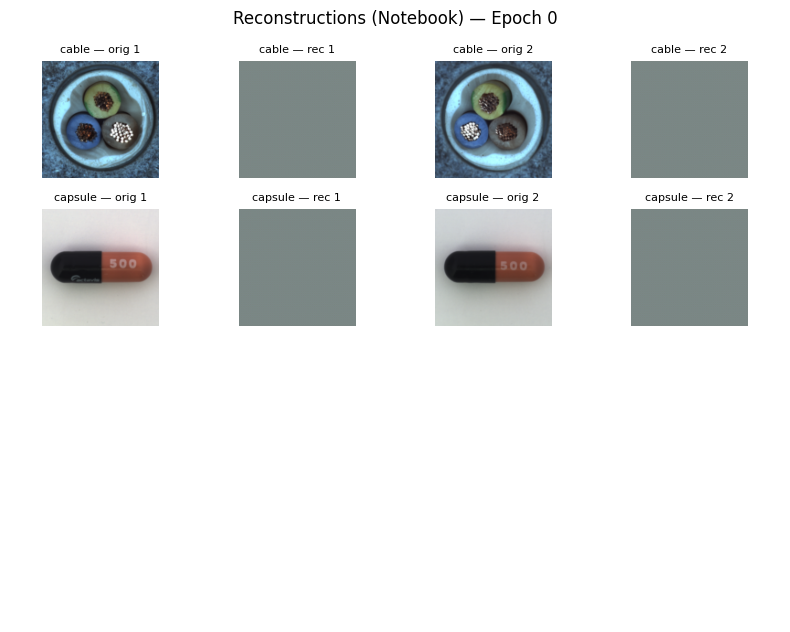

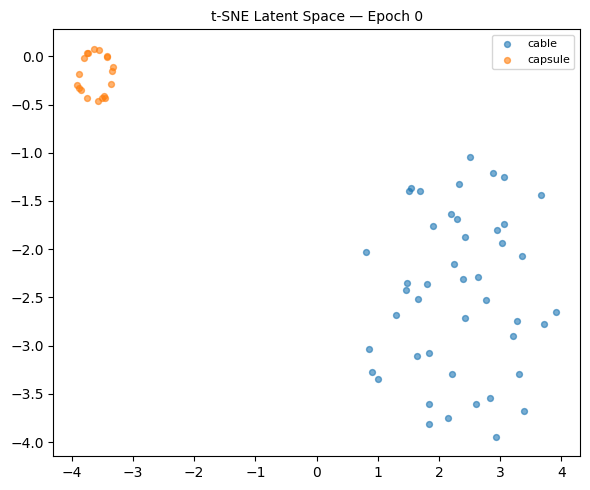

/home/javialroro/miniconda3/envs/ml/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/home/javialroro/miniconda3/envs/ml/lib/python3.13/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (25) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 0: 100%|██████████| 25/25 [00:25<00:00,  0.99it/s, v_num=7j9v, train_loss=0.174]

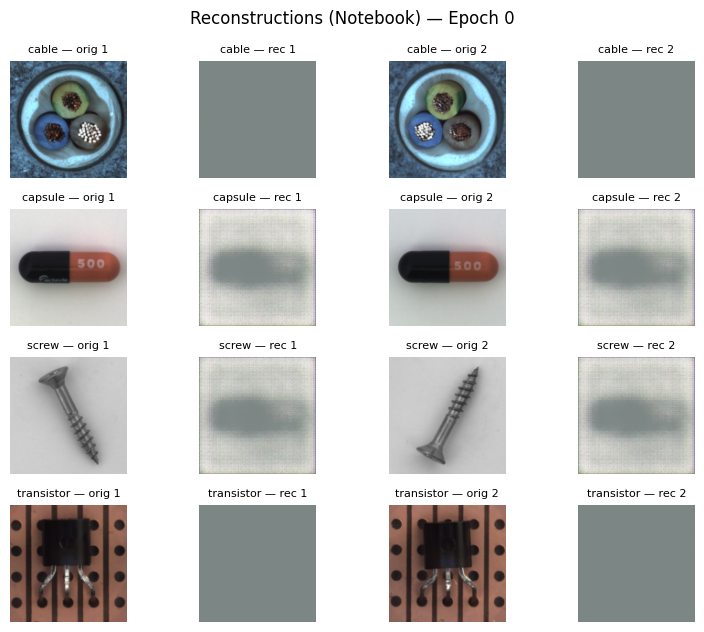

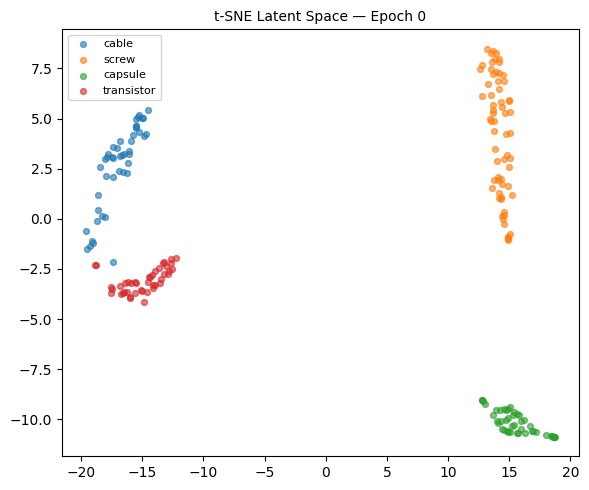

Epoch 10: 100%|██████████| 25/25 [00:26<00:00,  0.93it/s, v_num=7j9v, train_loss=0.0514, val_loss=0.056]

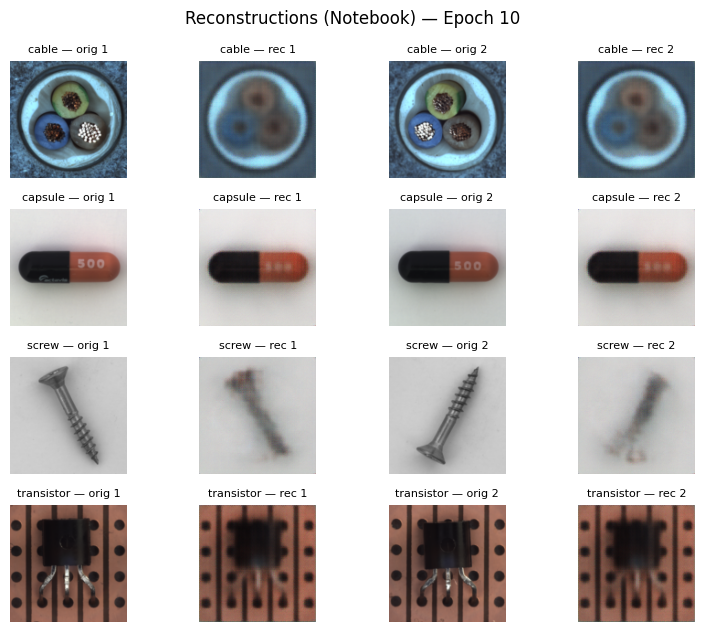

Epoch 20: 100%|██████████| 25/25 [00:29<00:00,  0.86it/s, v_num=7j9v, train_loss=0.0382, val_loss=0.0423]

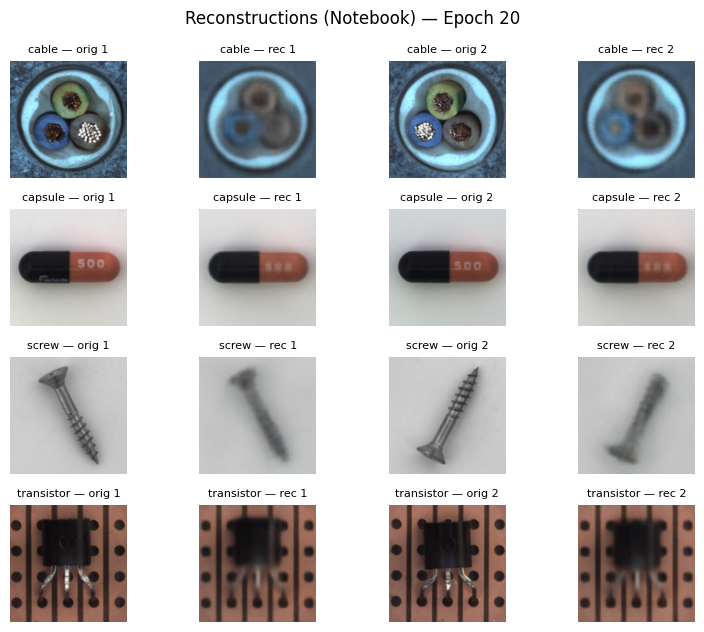

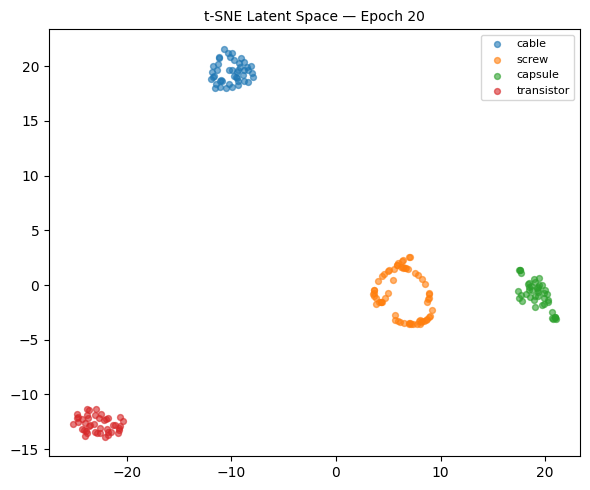

Epoch 30: 100%|██████████| 25/25 [00:30<00:00,  0.82it/s, v_num=7j9v, train_loss=0.0306, val_loss=0.0374]

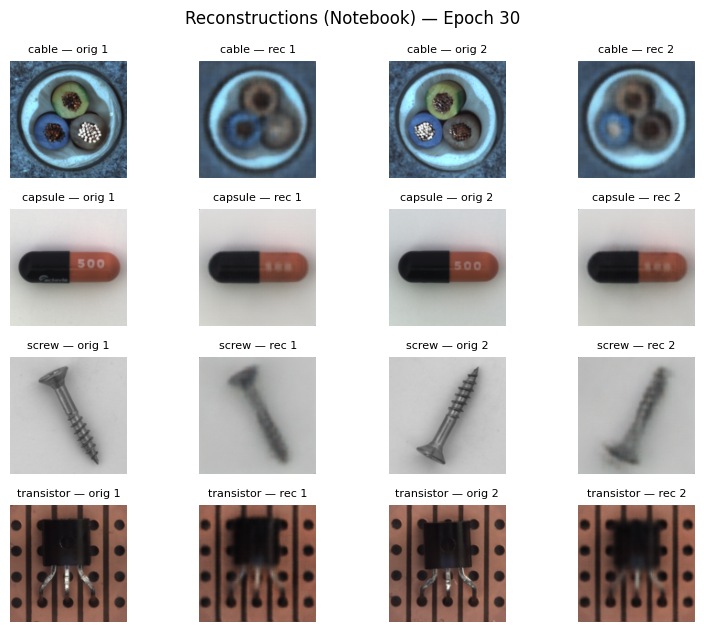

Epoch 40: 100%|██████████| 25/25 [00:29<00:00,  0.84it/s, v_num=7j9v, train_loss=0.0359, val_loss=0.0396]

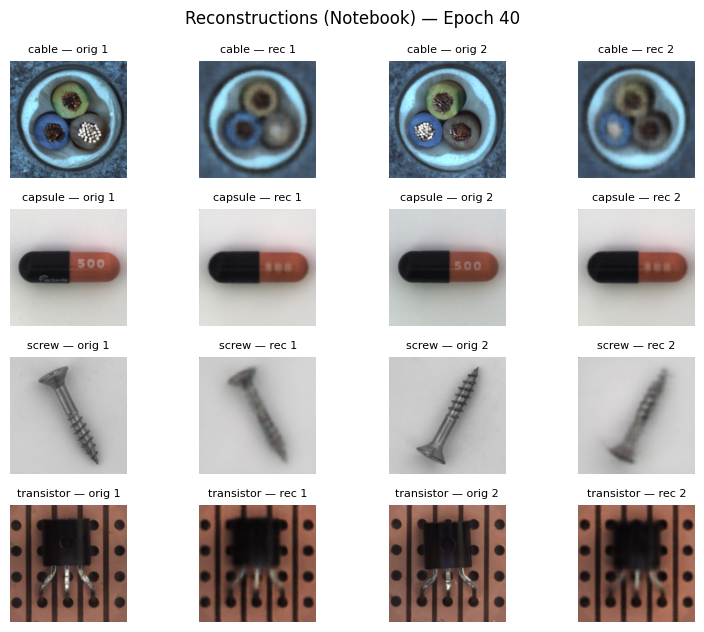

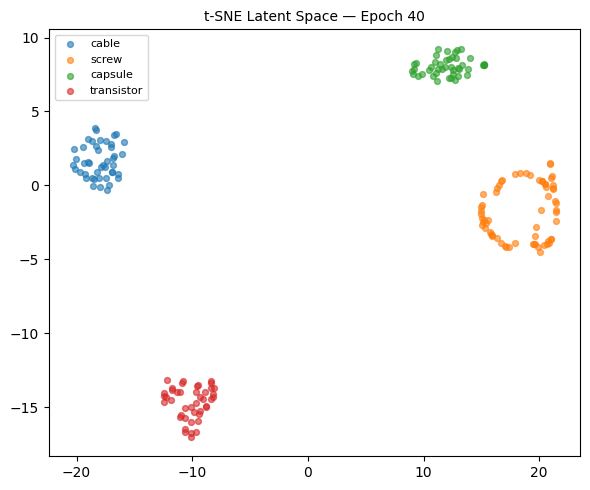

Epoch 49: 100%|██████████| 25/25 [00:31<00:00,  0.81it/s, v_num=7j9v, train_loss=0.0301, val_loss=0.0345]

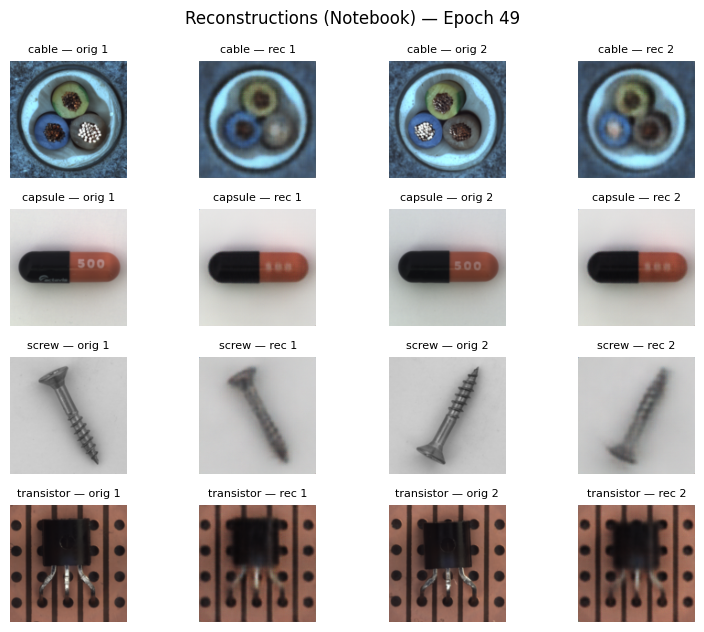

Epoch 49: 100%|██████████| 25/25 [00:39<00:00,  0.64it/s, v_num=7j9v, train_loss=0.0301, val_loss=0.033] 

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 25/25 [00:39<00:00,  0.64it/s, v_num=7j9v, train_loss=0.0301, val_loss=0.033]


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/javialroro/miniconda3/envs/ml/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


[INFO] Train: 780 imgs, Val: 196 imgs, Test: 542 imgs
Testing DataLoader 0: 100%|██████████| 17/17 [00:20<00:00,  0.81it/s]

...

Usando config dir: /home/javialroro/TEC/2025 II/IA/AutoencoderImageGen/conf

>>> Corriendo experimento: unet_l1
Experimento: unet_ae_l1


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/javialroro/miniconda3/envs/ml/lib/python3.13/site-packages/lightning/pytorch/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
/home/javialroro/miniconda3/envs/ml/lib/python3.13/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:751: Checkpoint directory ./wandb/tarea5-autoencoder/mz3t7j9v/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type   | Params | Mode 
-------------------------------------------
0 | model   | UNetAE | 6.3 M  | train
1 | loss_fn | L1Loss | 0      | train
-------------------------------------------
6.3 M     Trainable params
0         Non-trainable params
6.3 M     Total params
25.122    Total estimated model params size (MB)
29        Modules in train mode
0      

[INFO] Train: 780 imgs, Val: 196 imgs, Test: 542 imgs
Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/javialroro/miniconda3/envs/ml/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Sanity Checking DataLoader 0: 100%|██████████| 2/2 [00:01<00:00,  1.38it/s]

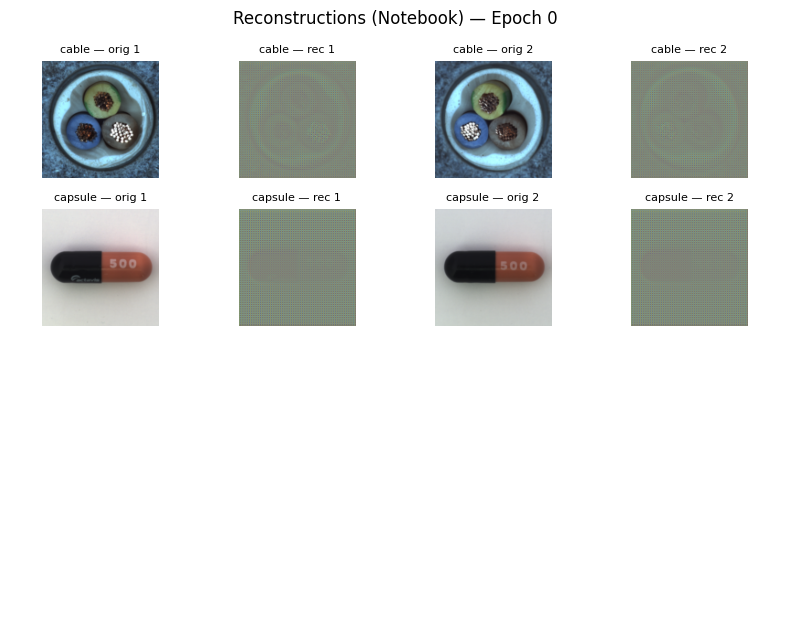

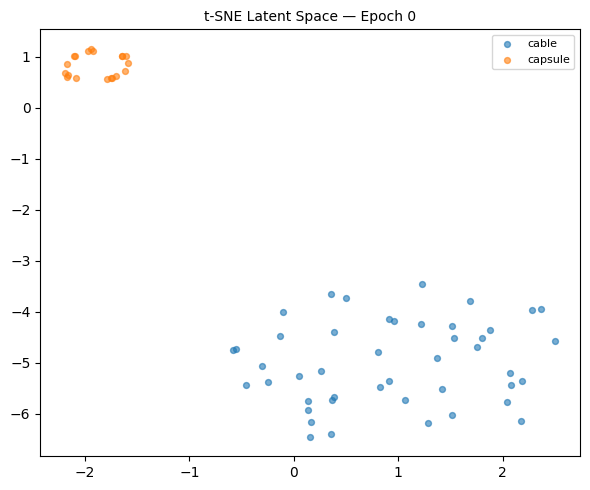

/home/javialroro/miniconda3/envs/ml/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/home/javialroro/miniconda3/envs/ml/lib/python3.13/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (25) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 0: 100%|██████████| 25/25 [00:33<00:00,  0.74it/s, v_num=7j9v, train_loss=0.0909]

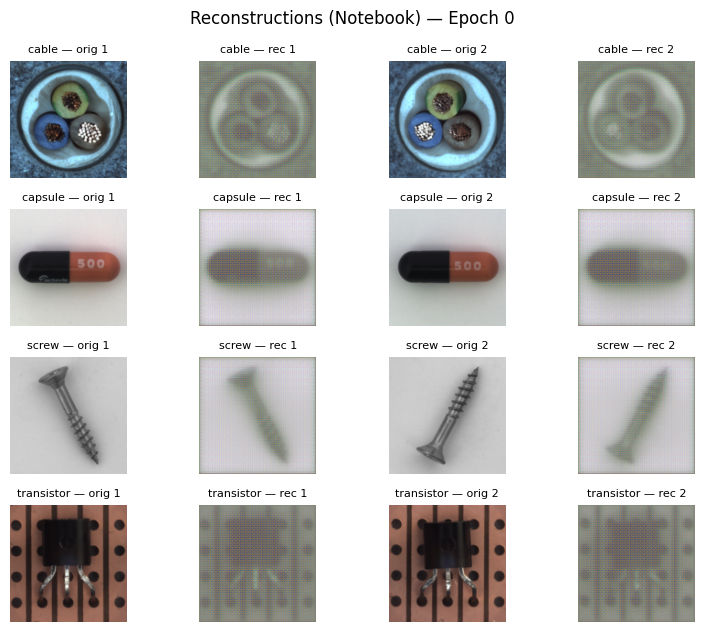

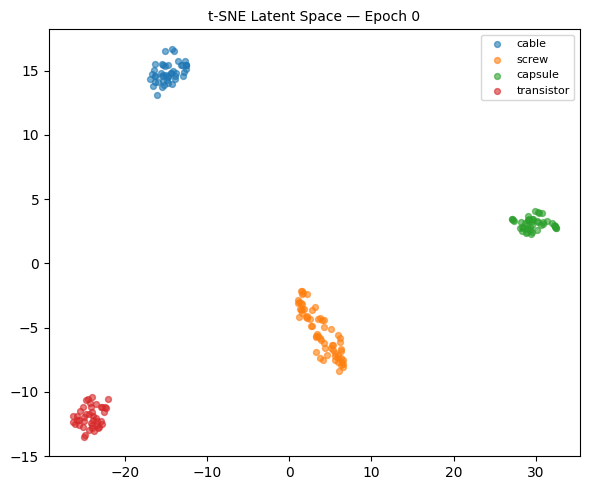

Epoch 2:  80%|████████  | 20/25 [00:28<00:07,  0.70it/s, v_num=7j9v, train_loss=0.0554, val_loss=0.0546]


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/home/javialroro/miniconda3/envs/ml/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x729500319d30>> (for post_run_cell), with arguments args (<ExecutionResult object at 729501226050, execution_count=20 error_before_exec=None error_in_exec=1 info=<ExecutionInfo object at 7295012276d0, raw_cell="experiments = ["classic_l1", "unet_l1", "classic_l.." transformed_cell="experiments = ["classic_l1", "unet_l1", "classic_l.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/home/javialroro/TEC/2025%20II/IA/AutoencoderImageGen/source.ipynb#X53sZmlsZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

In [20]:
experiments = ["classic_l1", "unet_l1", "classic_l2", "unet_l2", "classic_ssim", "unet_ssim", "classic_ssim_l1", "unet_ssim_l1"]
for exp in experiments:
    run_single_experiment(exp)